In [2]:
# =========================================
# 01_bootstrap.ipynb - Cell 1 (SSOT 강제본)
# 목적:
# 1) 프로젝트 루트(QP2_ROOT)를 단일 진실로 '강제'
# 2) .env 로드 (민감 설정 분리)
# 3) 로깅/세션 기본값 세팅
# =========================================

from __future__ import annotations

import os
from pathlib import Path
from datetime import datetime
import logging
import pandas as pd
from dotenv import load_dotenv

# ---- 1) .env 로드 ------------------------------------------------------------
load_dotenv()

# ---- 2) 프로젝트 ROOT 강제 ----------------------------------------------------
# 이 프로젝트에서는 "추정"을 허용하지 않음
env_root = os.getenv("QP2_ROOT", "").strip()
if not env_root:
    raise RuntimeError(
        "QP2_ROOT가 .env에 정의되어 있지 않소.\n"
        "반드시 .env에 다음을 명시하시오:\n"
        "QP2_ROOT=C:/QP2"
    )

QP2_ROOT = Path(env_root).resolve()
EXPECTED_ROOT = Path("C:/QP2").resolve()

if QP2_ROOT != EXPECTED_ROOT:
    raise RuntimeError(
        f"QP2_ROOT 불일치:\n"
        f"  env QP2_ROOT = {QP2_ROOT}\n"
        f"  expected     = {EXPECTED_ROOT}\n"
        f"루트를 바로잡고 다시 실행하시오."
    )

# ---- 3) 표준 디렉토리 (SSOT) --------------------------------------------------
DATA_DIR = QP2_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
META_DIR = DATA_DIR / "meta"

for p in [RAW_DIR, INTERIM_DIR, PROCESSED_DIR, META_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# ---- 4) 기본 설정값 -----------------------------------------------------------
SEC_USER_AGENT = os.getenv("SEC_USER_AGENT", "").strip()
SEC_RATE_LIMIT_PER_SEC = float(os.getenv("SEC_RATE_LIMIT_PER_SEC", "8"))
HTTP_TIMEOUT = int(os.getenv("HTTP_TIMEOUT", "30"))

if not SEC_USER_AGENT:
    raise RuntimeError(
        "SEC_USER_AGENT가 비어있소.\n"
        ".env에 '이름 이메일' 형식으로 넣으시오."
    )

# ---- 5) 로깅 ------------------------------------------------------------------
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
)
logger = logging.getLogger("qp2")

logger.info("QP2_ROOT = %s", QP2_ROOT)
logger.info("DATA_DIR = %s", DATA_DIR)
logger.info(
    "SEC_RATE_LIMIT_PER_SEC=%s | HTTP_TIMEOUT=%s",
    SEC_RATE_LIMIT_PER_SEC,
    HTTP_TIMEOUT,
)

# ---- 6) 실행 스냅샷 -----------------------------------------------------------
snapshot = {
    "run_utc": datetime.utcnow().isoformat(timespec="seconds"),
    "qp2_root": str(QP2_ROOT),
    "sec_rate_limit_per_sec": SEC_RATE_LIMIT_PER_SEC,
    "http_timeout": HTTP_TIMEOUT,
}
pd.Series(snapshot).to_json(META_DIR / "last_run_snapshot.json", force_ascii=False)

# ---- 7) 표준 저장 함수 --------------------------------------------------------
def save_parquet(df: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(path, index=False)

logger.info("Bootstrap complete (SSOT locked).")


2026-01-26 16:53:13,440 | INFO | qp2 | QP2_ROOT = C:\QP2
2026-01-26 16:53:13,441 | INFO | qp2 | DATA_DIR = C:\QP2\data
2026-01-26 16:53:13,442 | INFO | qp2 | SEC_RATE_LIMIT_PER_SEC=8.0 | HTTP_TIMEOUT=30
C:\Users\이노\AppData\Local\Temp\ipykernel_24636\418771218.py:80: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "run_utc": datetime.utcnow().isoformat(timespec="seconds"),
2026-01-26 16:53:13,447 | INFO | qp2 | Bootstrap complete (SSOT locked).


In [3]:
# =========================================
# 01_bootstrap.ipynb - Cell 2 (방탄판)
# - SEC ticker->CIK map 다운로드 + 캐시 + 상세 에러 출력
# =========================================

import requests
import pandas as pd
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type

SEC_TICKER_CIK_URL = "https://www.sec.gov/files/company_tickers.json"
OUT_PATH = META_DIR / "sec_ticker_cik.parquet"

# 0) 필수값 점검 (여기서 터지면 .env 문제)
if not SEC_USER_AGENT or not SEC_USER_AGENT.strip():
    raise RuntimeError("SEC_USER_AGENT 비어있소. .env에 '이름 이메일' 형태로 넣으시오.")

session = requests.Session()

@retry(
    reraise=True,
    stop=stop_after_attempt(6),
    wait=wait_exponential(multiplier=1, min=1, max=30),
    retry=retry_if_exception_type((requests.RequestException,)),
)
def fetch_sec_json(url: str) -> dict:
    """
    SEC는 403/429/일시 네트워크 에러가 잦아 재시도 포함.
    실패 시 상태코드/본문 일부까지 출력해 원인 추적 가능하게 함.
    """
    headers = {
        "User-Agent": SEC_USER_AGENT,
        "Accept": "application/json",
        "Accept-Encoding": "gzip, deflate",
        "Connection": "keep-alive",
    }
    r = session.get(url, headers=headers, timeout=HTTP_TIMEOUT)

    # 에러면 상세 로그
    if not r.ok:
        body_head = (r.text or "")[:300].replace("\n", " ")
        raise requests.HTTPError(
            f"SEC request failed: status={r.status_code}, body_head={body_head}"
        )

    return r.json()


def download_sec_ticker_cik(force: bool = False) -> pd.DataFrame:
    # 1) 캐시 있으면 재사용
    if OUT_PATH.exists() and not force:
        logger.info("Using cached SEC ticker map: %s", OUT_PATH)
        return pd.read_parquet(OUT_PATH)

    # 2) 다운로드
    logger.info("Downloading SEC ticker->CIK map: %s", SEC_TICKER_CIK_URL)
    raw = fetch_sec_json(SEC_TICKER_CIK_URL)

    # 3) 정규화
    rows = []
    for _, v in raw.items():
        rows.append(
            {
                "ticker": str(v["ticker"]).upper().strip(),
                "cik": str(v["cik_str"]).zfill(10),
                "title": str(v.get("title", "")).strip(),
            }
        )

    df = (
        pd.DataFrame(rows)
        .dropna(subset=["ticker", "cik"])
        .drop_duplicates(subset=["ticker"])
        .sort_values("ticker")
        .reset_index(drop=True)
    )

    # 4) 저장
    save_parquet(df, OUT_PATH)
    logger.info("Saved SEC ticker map (%d rows) -> %s", len(df), OUT_PATH)
    return df


# 실행
sec_map = download_sec_ticker_cik(force=False)
sec_map.head(10)


2026-01-26 16:53:13,535 | INFO | qp2 | Using cached SEC ticker map: C:\QP2\data\meta\sec_ticker_cik.parquet


,ticker,cik,title
0,A,0001090872,"AGILENT TECHNOLOGIES, INC."
1,AA,0001675149,Alcoa Corp
2,AAAU,0001708646,Goldman Sachs Physical Gold ETF
3,AACB,0002034334,Artius II Acquisition Inc.
4,AACBR,0002034334,Artius II Acquisition Inc.
5,AACBU,0002034334,Artius II Acquisition Inc.
6,AACG,0001420529,ATA Creativity Global
7,AACO,0002099906,Abony Acquisition Corp. I
8,AAL,0000006201,American Airlines Group Inc.
9,AAM,0002012964,AA Mission Acquisition Corp.


In [4]:
# =========================================
# 01_bootstrap.ipynb - Cell 3 (Wikipedia 403 우회)
# 목적:
# 1) Wikipedia에서 S&P500 구성 테이블을 "requests + UA"로 가져온다
# 2) Yahoo 표기(점->대시)로 티커 표준화
# 3) SEC ticker->CIK(sec_map)과 결합하여 master_universe 생성
# 4) meta에 저장 + unmatched 저장
# =========================================

import pandas as pd
import requests
from io import StringIO

SP500_URL = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

OUT_UNIVERSE = META_DIR / "sp500_universe.parquet"
OUT_UNMATCHED = META_DIR / "sp500_unmatched.parquet"

def to_yahoo_ticker(t: str) -> str:
    return str(t).upper().strip().replace(".", "-")

def fetch_html(url: str) -> str:
    # Wikipedia 403 우회: 브라우저 흉내
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
                      "(KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
        "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
        "Accept-Language": "en-US,en;q=0.9",
        "Connection": "keep-alive",
    }
    r = requests.get(url, headers=headers, timeout=HTTP_TIMEOUT)
    r.raise_for_status()
    return r.text

logger.info("Loading S&P500 table from Wikipedia (UA bypass)")
html = fetch_html(SP500_URL)

# read_html은 문자열을 받으면 파일처럼 읽을 수 있어야 하므로 StringIO로 감싼다
tables = pd.read_html(StringIO(html))
sp = tables[0].copy()
sp.columns = [c.strip() for c in sp.columns]

# 방어적 체크
if "Symbol" not in sp.columns or "Security" not in sp.columns:
    raise RuntimeError(f"Unexpected Wikipedia table columns: {list(sp.columns)}")

# S&P500 쪽 티커 정리
sp["ticker_sp"] = sp["Symbol"].astype(str).str.upper().str.strip()
sp["ticker_yahoo"] = sp["ticker_sp"].map(to_yahoo_ticker)
sp["join_key"] = sp["ticker_yahoo"]

# SEC 쪽도 join_key 생성 (충돌 방지 위해 필요한 컬럼만 남김)
sec_key = sec_map.copy()
sec_key["join_key"] = sec_key["ticker"].map(to_yahoo_ticker)
sec_key = (
    sec_key[["join_key", "cik", "title"]]
    .drop_duplicates(subset=["join_key"])
)

# 매칭
master = sp.merge(sec_key, on="join_key", how="left")
master = master.rename(columns={"Security": "security_name"})

# 최종 컬럼 정리
keep_cols = ["ticker_sp", "ticker_yahoo", "cik", "security_name"]
for c in ["GICS Sector", "GICS Sub-Industry"]:
    if c in master.columns:
        keep_cols.append(c)

master = master[keep_cols].copy()
unmatched = master[master["cik"].isna()].copy()

# 저장
save_parquet(master, OUT_UNIVERSE)
save_parquet(unmatched, OUT_UNMATCHED)

logger.info("Saved universe: %s (rows=%d, match_rate=%.4f)",
            OUT_UNIVERSE, len(master), master["cik"].notna().mean())
logger.info("Unmatched: %s (rows=%d)", OUT_UNMATCHED, len(unmatched))

master.head(10), float(master["cik"].notna().mean()), unmatched.head(10)


2026-01-26 16:53:13,592 | INFO | qp2 | Loading S&P500 table from Wikipedia (UA bypass)
2026-01-26 16:53:14,584 | INFO | qp2 | Saved universe: C:\QP2\data\meta\sp500_universe.parquet (rows=503, match_rate=1.0000)
2026-01-26 16:53:14,584 | INFO | qp2 | Unmatched: C:\QP2\data\meta\sp500_unmatched.parquet (rows=0)


(  ticker_sp ticker_yahoo         cik           security_name  \
 0       MMM          MMM  0000066740                      3M   
 1       AOS          AOS  0000091142             A. O. Smith   
 2       ABT          ABT  0000001800     Abbott Laboratories   
 3      ABBV         ABBV  0001551152                  AbbVie   
 4       ACN          ACN  0001467373               Accenture   
 5      ADBE         ADBE  0000796343              Adobe Inc.   
 6       AMD          AMD  0000002488  Advanced Micro Devices   
 7       AES          AES  0000874761         AES Corporation   
 8       AFL          AFL  0000004977                   Aflac   
 9         A            A  0001090872    Agilent Technologies   
 
               GICS Sector                             GICS Sub-Industry  
 0             Industrials                      Industrial Conglomerates  
 1             Industrials                             Building Products  
 2             Health Care                         Health 

In [9]:
# =========================================
# 01_bootstrap.ipynb - Cell 4
# 목적:
# 1) master_universe 기준 Yahoo 일봉 수집
# 2) 종목별 parquet 저장
# 3) 중단/재개 가능 구조
# =========================================

import yfinance as yf
from tqdm import tqdm
import pandas as pd
import time

YAHOO_DIR = RAW_DIR / "yahoo"
YAHOO_DIR.mkdir(parents=True, exist_ok=True)

FAILED_PATH = META_DIR / "yahoo_failed.parquet"


def download_one(ticker: str) -> pd.DataFrame | None:
    try:
        df = yf.download(
            ticker,
            start="1900-01-01",
            progress=False,
            threads=False,
        )
        if df.empty:
            return None
        df = df.reset_index()
        df["ticker"] = ticker
        return df
    except Exception as e:
        logger.warning("Yahoo failed: %s | %s", ticker, e)
        return None


failed = []

logger.info("Start Yahoo download (%d tickers)", len(master))

for _, row in tqdm(master.iterrows(), total=len(master)):
    t = row["ticker_yahoo"]
    out = YAHOO_DIR / f"{t}.parquet"

    if out.exists():
        continue

    df = download_one(t)
    if df is None:
        failed.append({"ticker": t})
        continue

    save_parquet(df, out)
    time.sleep(0.2)

failed_df = pd.DataFrame(failed)
save_parquet(failed_df, FAILED_PATH)

logger.info("Yahoo done. Failed=%d", len(failed_df))


2026-01-26 16:59:08,149 | INFO | qp2 | Start Yahoo download (503 tickers)
100%|██████████| 503/503 [08:25<00:00,  1.00s/it]
2026-01-26 17:07:33,201 | INFO | qp2 | Yahoo done. Failed=0


In [13]:
# =========================================
# 5) Yahoo 가격 패널 생성 (503개 parquet 결합) - 문자열 튜플 컬럼까지 대응 (확정판)
# =========================================

from pathlib import Path
import pandas as pd
import ast

YAHOO_DIR = RAW_DIR / "yahoo"
OUT_LONG = INTERIM_DIR / "yahoo_prices_long.parquet"
OUT_WIDE = INTERIM_DIR / "yahoo_adjclose_wide.parquet"

assert YAHOO_DIR.exists(), f"YAHOO_DIR not found: {YAHOO_DIR}"
INTERIM_DIR.mkdir(parents=True, exist_ok=True)

paths = sorted(Path(YAHOO_DIR).glob("*.parquet"))
if len(paths) == 0:
    raise FileNotFoundError(f"No parquet files in {YAHOO_DIR}")

logger.info(f"[Cell5] Yahoo parquet files found: {len(paths)}")

def _flatten_one(col):
    """
    col이
    - tuple: ('Close','A')
    - 문자열 튜플: "('Close', 'A')"
    - 일반 문자열: 'Close'
    모두를 'Close'로 평탄화
    """
    if isinstance(col, tuple):
        return str(col[0]).strip()

    s = str(col).strip()

    # 문자열로 저장된 튜플 형태면 파싱 시도
    if s.startswith("(") and s.endswith(")"):
        try:
            v = ast.literal_eval(s)
            if isinstance(v, tuple) and len(v) > 0:
                return str(v[0]).strip()
        except Exception:
            pass

    return s

def _load_one_yahoo_parquet(path: Path) -> pd.DataFrame:
    ticker = path.stem
    df = pd.read_parquet(path)

    # --- 컬럼 평탄화 ---
    df.columns = [_flatten_one(c) for c in df.columns]

    # --- date ---
    if "Date" in df.columns:
        date = pd.to_datetime(df["Date"], errors="coerce")
    elif "date" in df.columns:
        date = pd.to_datetime(df["date"], errors="coerce")
    else:
        tmp = df.reset_index()
        date = pd.to_datetime(tmp.iloc[:, 0], errors="coerce")

    # --- price ---
    if "Adj Close" in df.columns:
        price = df["Adj Close"]
    elif "Close" in df.columns:
        price = df["Close"]
    else:
        # 디버그 힌트: 어떤 컬럼이 있는지 일부를 포함해 던짐
        raise KeyError(f"{ticker}: no Close/Adj Close. cols_head={list(df.columns)[:10]}")

    out = pd.DataFrame(
        {
            "date": date,
            "ticker": ticker,
            "adj_close": pd.to_numeric(price, errors="coerce"),
        }
    ).dropna(subset=["date"]).sort_values("date")

    return out

chunks = []
for p in paths:
    chunks.append(_load_one_yahoo_parquet(p))

prices_long = pd.concat(chunks, ignore_index=True)
prices_long = prices_long.drop_duplicates(["ticker", "date"]).sort_values(["ticker", "date"])

prices_wide = prices_long.pivot(index="date", columns="ticker", values="adj_close").sort_index()

logger.info(f"[Cell5] Long rows: {len(prices_long):,}")
logger.info(f"[Cell5] Tickers: {prices_long['ticker'].nunique():,}")
logger.info(f"[Cell5] Date range: {prices_long['date'].min().date()} ~ {prices_long['date'].max().date()}")
logger.info(f"[Cell5] Wide missing rate: {prices_wide.isna().mean().mean():.4%}")

save_parquet(prices_long, OUT_LONG)
save_parquet(prices_wide.reset_index(), OUT_WIDE)

logger.info(f"[Cell5] Saved long: {OUT_LONG}")
logger.info(f"[Cell5] Saved wide: {OUT_WIDE}")

display(prices_long.head())
display(prices_wide.head())


2026-01-26 17:16:46,648 | INFO | qp2 | [Cell5] Yahoo parquet files found: 503
2026-01-26 17:16:54,179 | INFO | qp2 | [Cell5] Long rows: 4,341,475
2026-01-26 17:16:54,240 | INFO | qp2 | [Cell5] Tickers: 503
2026-01-26 17:16:54,258 | INFO | qp2 | [Cell5] Date range: 1962-01-02 ~ 2026-01-23
2026-01-26 17:16:54,273 | INFO | qp2 | [Cell5] Wide missing rate: 46.4668%
2026-01-26 17:16:55,414 | INFO | qp2 | [Cell5] Saved long: C:\QP2\data\interim\yahoo_prices_long.parquet
2026-01-26 17:16:55,415 | INFO | qp2 | [Cell5] Saved wide: C:\QP2\data\interim\yahoo_adjclose_wide.parquet


,date,ticker,adj_close
0,1999-11-18,A,26.300028
1,1999-11-19,A,24.133259
2,1999-11-22,A,26.300028
3,1999-11-23,A,23.909111
4,1999-11-24,A,24.544195


ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
date,,,,,,,,,,,,,,,,,,,,,
1962-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.089345,NaN,NaN,NaN,NaN,NaN,NaN
1962-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.090672,NaN,NaN,NaN,NaN,NaN,NaN
1962-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.090893,NaN,NaN,NaN,NaN,NaN,NaN
1962-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.088903,NaN,NaN,NaN,NaN,NaN,NaN
1962-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.088682,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# =========================================
# 5.2) 커버리지 점검 + 시작일 추천
# 목적:
# - 왜 NaN이 많은지 수치로 확인
# - (예) 90% 커버리지 달성 날짜를 찾아 패널 절단
# =========================================

import pandas as pd

# wide는 date 컬럼이 있을 수 있으니 표준 로드
wide = pd.read_parquet(INTERIM_DIR / "yahoo_adjclose_wide.parquet")
wide["date"] = pd.to_datetime(wide["date"])
wide = wide.set_index("date").sort_index()

# 날짜별 커버리지(값 존재 비율)
coverage = 1.0 - wide.isna().mean(axis=1)

logger.info("[Cell5.2] coverage min=%.2f%% max=%.2f%%", coverage.min()*100, coverage.max()*100)

# 추천 시작일: 커버리지 90% 이상이 처음 달성되는 날짜
THRESH = 0.90
hit = coverage[coverage >= THRESH]
if len(hit) == 0:
    logger.warning("[Cell5.2] No date reaches %.0f%% coverage", THRESH*100)
    recommended_start = wide.index.min()
else:
    recommended_start = hit.index.min()

logger.info("[Cell5.2] recommended_start (>=%.0f%% coverage) = %s", THRESH*100, recommended_start.date())

# 추천 시작일로 절단한 wide 저장(선택)
OUT_WIDE_TRIM = INTERIM_DIR / "yahoo_adjclose_wide_trim.parquet"
wide_trim = wide.loc[recommended_start:].reset_index()
save_parquet(wide_trim, OUT_WIDE_TRIM)
logger.info("[Cell5.2] Saved trimmed wide: %s", OUT_WIDE_TRIM)

display(pd.DataFrame({
    "coverage": coverage,
}).head(10))
display(pd.DataFrame({
    "coverage": coverage,
}).loc[recommended_start:recommended_start].head(1))


2026-01-26 17:20:14,005 | INFO | qp2 | [Cell5.2] coverage min=4.77% max=100.00%
2026-01-26 17:20:14,006 | INFO | qp2 | [Cell5.2] recommended_start (>=90% coverage) = 2013-06-19
2026-01-26 17:20:14,234 | INFO | qp2 | [Cell5.2] Saved trimmed wide: C:\QP2\data\interim\yahoo_adjclose_wide_trim.parquet


,coverage
date,
1962-01-02,0.047714
1962-01-03,0.047714
1962-01-04,0.047714
1962-01-05,0.047714
1962-01-08,0.047714
1962-01-09,0.047714
1962-01-10,0.047714
1962-01-11,0.047714
1962-01-12,0.047714


,coverage
date,
2013-06-19,0.900596


In [15]:
# =========================================
# 5.3) 분석 구간 고정 (2013-06-19 이후만)
#
# 목적:
# - 커버리지 기반으로 선택한 시작일 이후만 사용해 패널을 "확정"
#
# 산출물:
# - data/interim/yahoo_prices_long_20130619.parquet
# - data/interim/yahoo_adjclose_wide_20130619.parquet
# =========================================

import pandas as pd

START_DATE = pd.Timestamp("2013-06-19")

IN_LONG = INTERIM_DIR / "yahoo_prices_long.parquet"
IN_WIDE = INTERIM_DIR / "yahoo_adjclose_wide.parquet"

OUT_LONG = INTERIM_DIR / "yahoo_prices_long_20130619.parquet"
OUT_WIDE = INTERIM_DIR / "yahoo_adjclose_wide_20130619.parquet"

# --- long ---
prices_long = pd.read_parquet(IN_LONG)
prices_long["date"] = pd.to_datetime(prices_long["date"])
prices_long_trim = prices_long.loc[prices_long["date"] >= START_DATE].copy()

# --- wide (저장 형태: date 컬럼 포함) ---
wide = pd.read_parquet(IN_WIDE)
wide["date"] = pd.to_datetime(wide["date"])
wide_trim = wide.loc[wide["date"] >= START_DATE].copy()

save_parquet(prices_long_trim, OUT_LONG)
save_parquet(wide_trim, OUT_WIDE)

logger.info("[Cell5.3] START_DATE = %s", START_DATE.date())
logger.info("[Cell5.3] long rows: %d -> %d", len(prices_long), len(prices_long_trim))
logger.info("[Cell5.3] wide rows: %d -> %d", len(wide), len(wide_trim))
logger.info("[Cell5.3] Saved long: %s", OUT_LONG)
logger.info("[Cell5.3] Saved wide: %s", OUT_WIDE)

display(prices_long_trim.head())
display(wide_trim.head())


2026-01-26 17:22:39,383 | INFO | qp2 | [Cell5.3] START_DATE = 2013-06-19
2026-01-26 17:22:39,384 | INFO | qp2 | [Cell5.3] long rows: 4341475 -> 1529580
2026-01-26 17:22:39,385 | INFO | qp2 | [Cell5.3] wide rows: 16123 -> 3169
2026-01-26 17:22:39,385 | INFO | qp2 | [Cell5.3] Saved long: C:\QP2\data\interim\yahoo_prices_long_20130619.parquet
2026-01-26 17:22:39,386 | INFO | qp2 | [Cell5.3] Saved wide: C:\QP2\data\interim\yahoo_adjclose_wide_20130619.parquet


,date,ticker,adj_close
3415,2013-06-19,A,27.964163
3416,2013-06-20,A,27.193087
3417,2013-06-21,A,27.617174
3418,2013-06-24,A,27.186659
3419,2013-06-25,A,27.295897


,date,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
12954,2013-06-19,27.964163,12.958675,25.947289,NaN,28.346796,16.247686,65.803947,45.779999,35.232555,...,16.961235,110.956398,19.050953,54.460171,23.188704,NaN,40.483967,68.102417,44.980000,27.964764
12955,2013-06-20,27.193087,12.769963,24.753632,NaN,27.532633,16.076525,63.946369,44.900002,34.184143,...,16.787338,106.376793,18.490437,53.293194,22.473904,NaN,39.283787,65.917915,44.040001,27.234079
12956,2013-06-21,27.617174,12.667640,25.694090,NaN,27.853611,15.943398,63.849888,44.770000,34.559120,...,17.029554,104.380753,18.690626,53.550514,22.210112,NaN,39.051670,66.739311,43.970001,27.603935
12957,2013-06-24,27.186659,12.331880,25.253998,NaN,27.376064,15.899023,63.656853,43.599998,33.694382,...,16.774916,99.897751,18.697298,52.952061,21.929283,NaN,38.553467,65.769386,42.869999,27.405478
12958,2013-06-25,27.295897,12.334637,25.700127,NaN,27.485666,15.880006,64.058937,44.369999,34.069359,...,17.091660,101.088928,18.937517,53.329090,22.065434,NaN,38.689346,65.507240,43.139999,28.406790


In [17]:
# =========================================
# 6) 수익률 패널 생성 (2013-06-19 이후)
#
# 목적:
# - Adj Close 기반 일간 수익률(단순/로그) 생성
# - 월간(월말) 가격/수익률 생성
#
# 산출물:
# - data/interim/yahoo_returns_daily_long_20130619.parquet
# - data/interim/yahoo_prices_monthly_wide_20130619.parquet
# - data/interim/yahoo_returns_monthly_wide_20130619.parquet
#
# 주의:
# - wide는 date + ticker columns 형태로 저장됨
# - 수익률은 각 ticker별로 shift(1) 기반
# =========================================

import numpy as np
import pandas as pd

START_DATE = pd.Timestamp("2013-06-19")

IN_LONG = INTERIM_DIR / "yahoo_prices_long_20130619.parquet"
IN_WIDE = INTERIM_DIR / "yahoo_adjclose_wide_20130619.parquet"

OUT_DAILY_LONG = INTERIM_DIR / "yahoo_returns_daily_long_20130619.parquet"
OUT_MPRICE_WIDE = INTERIM_DIR / "yahoo_prices_monthly_wide_20130619.parquet"
OUT_MRET_WIDE = INTERIM_DIR / "yahoo_returns_monthly_wide_20130619.parquet"

# -----------------------------
# 1) long 로드 + 정렬
# -----------------------------
prices_long = pd.read_parquet(IN_LONG)
prices_long["date"] = pd.to_datetime(prices_long["date"])
prices_long = prices_long.loc[prices_long["date"] >= START_DATE].copy()
prices_long = prices_long.sort_values(["ticker", "date"])

# -----------------------------
# 2) 일간 수익률 (long)
# -----------------------------
# 단순수익률: r_t = P_t/P_{t-1} - 1
# 로그수익률: lr_t = log(P_t) - log(P_{t-1})
prices_long["ret_1d"] = prices_long.groupby("ticker")["adj_close"].pct_change(1)
prices_long["logret_1d"] = np.log(prices_long["adj_close"]) - np.log(prices_long.groupby("ticker")["adj_close"].shift(1))

returns_daily_long = prices_long[["date", "ticker", "adj_close", "ret_1d", "logret_1d"]].copy()

save_parquet(returns_daily_long, OUT_DAILY_LONG)
logger.info("[Cell6] Saved daily returns long: %s", OUT_DAILY_LONG)

# -----------------------------
# 3) wide 로드 (월간 생성용)
# -----------------------------
wide = pd.read_parquet(IN_WIDE)
wide["date"] = pd.to_datetime(wide["date"])
wide = wide.loc[wide["date"] >= START_DATE].copy()
wide = wide.set_index("date").sort_index()

# -----------------------------
# 4) 월말 가격 (wide)
# -----------------------------
# 월말(last valid observation)
monthly_price = wide.resample("ME").last()

# -----------------------------
# 5) 월간 수익률 (wide)
# -----------------------------
monthly_ret = monthly_price.pct_change(1)

# 저장 형태 통일: date 컬럼으로 내보냄
save_parquet(monthly_price.reset_index(), OUT_MPRICE_WIDE)
save_parquet(monthly_ret.reset_index(), OUT_MRET_WIDE)

logger.info("[Cell6] Saved monthly price wide: %s", OUT_MPRICE_WIDE)
logger.info("[Cell6] Saved monthly returns wide: %s", OUT_MRET_WIDE)

# -----------------------------
# 6) sanity check (핵심만)
# -----------------------------
logger.info("[Cell6] daily_long rows: %d", len(returns_daily_long))
logger.info("[Cell6] daily_long tickers: %d", returns_daily_long["ticker"].nunique())
logger.info("[Cell6] daily date range: %s ~ %s",
            returns_daily_long["date"].min().date(),
            returns_daily_long["date"].max().date())

logger.info("[Cell6] monthly rows: %d", len(monthly_price))
logger.info("[Cell6] monthly date range: %s ~ %s",
            monthly_price.index.min().date(),
            monthly_price.index.max().date())

display(returns_daily_long.head())
display(monthly_price.head())
display(monthly_ret.head())


2026-01-26 17:24:35,081 | INFO | qp2 | [Cell6] Saved daily returns long: C:\QP2\data\interim\yahoo_returns_daily_long_20130619.parquet
2026-01-26 17:24:35,337 | INFO | qp2 | [Cell6] Saved monthly price wide: C:\QP2\data\interim\yahoo_prices_monthly_wide_20130619.parquet
2026-01-26 17:24:35,338 | INFO | qp2 | [Cell6] Saved monthly returns wide: C:\QP2\data\interim\yahoo_returns_monthly_wide_20130619.parquet
2026-01-26 17:24:35,339 | INFO | qp2 | [Cell6] daily_long rows: 1529580
2026-01-26 17:24:35,361 | INFO | qp2 | [Cell6] daily_long tickers: 503
2026-01-26 17:24:35,368 | INFO | qp2 | [Cell6] daily date range: 2013-06-19 ~ 2026-01-23
2026-01-26 17:24:35,369 | INFO | qp2 | [Cell6] monthly rows: 152
2026-01-26 17:24:35,369 | INFO | qp2 | [Cell6] monthly date range: 2013-06-30 ~ 2026-01-31


,date,ticker,adj_close,ret_1d,logret_1d
0,2013-06-19,A,27.964163,NaN,NaN
1,2013-06-20,A,27.193087,-0.027574,-0.027961
2,2013-06-21,A,27.617174,0.015595,0.015475
3,2013-06-24,A,27.186659,-0.015589,-0.015711
4,2013-06-25,A,27.295897,0.004018,0.004010


,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
date,,,,,,,,,,,,,,,,,,,,,
2013-06-30,27.552561,12.147763,24.922421,NaN,27.305609,16.295231,57.866943,45.560001,34.482609,23.811907,...,17.694086,102.996422,18.910833,54.071186,22.924902,NaN,39.255466,65.656174,43.439999,27.865543
2013-07-31,28.821936,13.863329,27.670347,NaN,28.791620,17.170059,59.354641,47.279999,37.788525,25.609558,...,17.638197,107.149445,19.985157,56.105946,21.214476,NaN,41.472538,73.138229,46.169998,26.949497
2013-08-31,30.052662,15.024618,25.924229,NaN,26.197775,16.897467,58.100174,45.750000,35.679024,24.853868,...,17.142710,114.338272,18.630562,52.522621,21.185320,NaN,39.823200,69.292061,45.599998,26.352833
2013-09-30,33.099377,14.701755,27.214041,NaN,26.087732,17.157379,59.217926,51.939999,36.272633,26.004448,...,17.925331,128.095566,18.613922,51.847698,23.878380,NaN,40.602364,72.136337,45.560001,28.133801
2013-10-31,32.782921,16.118725,29.742821,NaN,28.850500,18.371359,59.888805,54.220001,38.007256,28.870295,...,19.182413,134.775574,19.456644,54.005009,29.618769,NaN,38.657799,76.817207,48.310001,28.680183


,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
date,,,,,,,,,,,,,,,,,,,,,
2013-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-07-31,0.046071,0.141225,0.110259,NaN,0.054421,0.053686,0.025709,0.037752,0.095872,0.075494,...,-0.003159,0.040322,0.056810,0.037631,-0.074610,NaN,0.056478,0.113958,0.062845,-0.032874
2013-08-31,0.042701,0.083767,-0.063104,NaN,-0.090090,-0.015876,-0.021135,-0.032360,-0.055824,-0.029508,...,-0.028092,0.067092,-0.067780,-0.063867,-0.001374,NaN,-0.039769,-0.052588,-0.012346,-0.022140
2013-09-30,0.101379,-0.021489,0.049753,NaN,-0.004200,0.015382,0.019238,0.135301,0.016637,0.046294,...,0.045653,0.120321,-0.000893,-0.012850,0.127119,NaN,0.019566,0.041048,-0.000877,0.067582
2013-10-31,-0.009561,0.096381,0.092922,NaN,0.105903,0.070756,0.011329,0.043897,0.047822,0.110206,...,0.070129,0.052149,0.045274,0.041609,0.240401,NaN,-0.047893,0.064889,0.060360,0.019421


In [18]:
# =========================================
# 7) 리밸런싱 캘린더 생성 (월말 / 분기말 / 연말)
#
# 목적:
# - 분석 구간(2013-06-19 이후)에 대해
#   월/분기/연 리밸런싱 날짜를 단일 기준으로 고정
#
# 산출물:
# - data/interim/rebal_calendar_monthly.parquet
# - data/interim/rebal_calendar_quarterly.parquet
# - data/interim/rebal_calendar_yearly.parquet
# =========================================

import pandas as pd

START_DATE = pd.Timestamp("2013-06-19")

# 월간 wide 가격에서 날짜만 추출 (가장 안전)
monthly_price = pd.read_parquet(
    INTERIM_DIR / "yahoo_prices_monthly_wide_20130619.parquet"
)
monthly_price["date"] = pd.to_datetime(monthly_price["date"])
monthly_price = monthly_price.loc[monthly_price["date"] >= START_DATE].copy()

# -----------------------------
# 1) 월말 리밸런싱
# -----------------------------
rebal_m = monthly_price[["date"]].drop_duplicates().sort_values("date")
rebal_m["freq"] = "M"

# -----------------------------
# 2) 분기말 리밸런싱
# -----------------------------
rebal_q = (
    rebal_m
    .assign(year=lambda x: x["date"].dt.year,
            quarter=lambda x: x["date"].dt.to_period("Q"))
    .groupby("quarter", as_index=False)
    .last()[["date"]]
)
rebal_q["freq"] = "Q"

# -----------------------------
# 3) 연말 리밸런싱
# -----------------------------
rebal_y = (
    rebal_m
    .assign(year=lambda x: x["date"].dt.year)
    .groupby("year", as_index=False)
    .last()[["date"]]
)
rebal_y["freq"] = "Y"

# -----------------------------
# 4) 저장
# -----------------------------
OUT_M = INTERIM_DIR / "rebal_calendar_monthly.parquet"
OUT_Q = INTERIM_DIR / "rebal_calendar_quarterly.parquet"
OUT_Y = INTERIM_DIR / "rebal_calendar_yearly.parquet"

save_parquet(rebal_m, OUT_M)
save_parquet(rebal_q, OUT_Q)
save_parquet(rebal_y, OUT_Y)

logger.info("[Cell7] Monthly rebal dates: %d", len(rebal_m))
logger.info("[Cell7] Quarterly rebal dates: %d", len(rebal_q))
logger.info("[Cell7] Yearly rebal dates: %d", len(rebal_y))

display(rebal_m.head())
display(rebal_q.head())
display(rebal_y.head())


2026-01-26 17:25:34,484 | INFO | qp2 | [Cell7] Monthly rebal dates: 152
2026-01-26 17:25:34,485 | INFO | qp2 | [Cell7] Quarterly rebal dates: 52
2026-01-26 17:25:34,485 | INFO | qp2 | [Cell7] Yearly rebal dates: 14


,date,freq
0,2013-06-30,M
1,2013-07-31,M
2,2013-08-31,M
3,2013-09-30,M
4,2013-10-31,M


,date,freq
0,2013-06-30,Q
1,2013-09-30,Q
2,2013-12-31,Q
3,2014-03-31,Q
4,2014-06-30,Q


,date,freq
0,2013-12-31,Y
1,2014-12-31,Y
2,2015-12-31,Y
3,2016-12-31,Y
4,2017-12-31,Y


In [19]:
# =========================================
# 8) 월간 수익률 + 리밸런싱 캘린더 결합
#
# 목적:
# - 월말 리밸런싱 날짜에 해당하는 월간 수익률만 추출
# - 이후 팩터/포트폴리오의 단일 입력으로 사용
#
# 산출물:
# - data/interim/yahoo_returns_monthly_rebal_20130619.parquet
# =========================================

import pandas as pd

# -----------------------------
# 1) 입력 로드
# -----------------------------
RET_M_PATH = INTERIM_DIR / "yahoo_returns_monthly_wide_20130619.parquet"
REBAL_M_PATH = INTERIM_DIR / "rebal_calendar_monthly.parquet"

monthly_ret = pd.read_parquet(RET_M_PATH)
monthly_ret["date"] = pd.to_datetime(monthly_ret["date"])
monthly_ret = monthly_ret.set_index("date").sort_index()

rebal_m = pd.read_parquet(REBAL_M_PATH)
rebal_m["date"] = pd.to_datetime(rebal_m["date"])
rebal_dates = rebal_m["date"].sort_values().unique()

# -----------------------------
# 2) 리밸런싱 날짜에 맞춰 슬라이싱
# -----------------------------
monthly_ret_rebal = monthly_ret.loc[monthly_ret.index.intersection(rebal_dates)].copy()

# -----------------------------
# 3) Sanity check
# -----------------------------
logger.info("[Cell8] monthly_ret rows (all): %d", len(monthly_ret))
logger.info("[Cell8] rebal dates: %d", len(rebal_dates))
logger.info("[Cell8] monthly_ret rows (rebal): %d", len(monthly_ret_rebal))
logger.info("[Cell8] date range: %s ~ %s",
            monthly_ret_rebal.index.min().date(),
            monthly_ret_rebal.index.max().date())

# -----------------------------
# 4) 저장
# -----------------------------
OUT = INTERIM_DIR / "yahoo_returns_monthly_rebal_20130619.parquet"
save_parquet(monthly_ret_rebal.reset_index(), OUT)
logger.info("[Cell8] Saved: %s", OUT)

display(monthly_ret_rebal.head())


2026-01-26 17:26:12,463 | INFO | qp2 | [Cell8] monthly_ret rows (all): 152
2026-01-26 17:26:12,464 | INFO | qp2 | [Cell8] rebal dates: 152
2026-01-26 17:26:12,465 | INFO | qp2 | [Cell8] monthly_ret rows (rebal): 152
2026-01-26 17:26:12,465 | INFO | qp2 | [Cell8] date range: 2013-06-30 ~ 2026-01-31
2026-01-26 17:26:12,541 | INFO | qp2 | [Cell8] Saved: C:\QP2\data\interim\yahoo_returns_monthly_rebal_20130619.parquet


,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
date,,,,,,,,,,,,,,,,,,,,,
2013-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-07-31,0.046071,0.141225,0.110259,NaN,0.054421,0.053686,0.025709,0.037752,0.095872,0.075494,...,-0.003159,0.040322,0.056810,0.037631,-0.074610,NaN,0.056478,0.113958,0.062845,-0.032874
2013-08-31,0.042701,0.083767,-0.063104,NaN,-0.090090,-0.015876,-0.021135,-0.032360,-0.055824,-0.029508,...,-0.028092,0.067092,-0.067780,-0.063867,-0.001374,NaN,-0.039769,-0.052588,-0.012346,-0.022140
2013-09-30,0.101379,-0.021489,0.049753,NaN,-0.004200,0.015382,0.019238,0.135301,0.016637,0.046294,...,0.045653,0.120321,-0.000893,-0.012850,0.127119,NaN,0.019566,0.041048,-0.000877,0.067582
2013-10-31,-0.009561,0.096381,0.092922,NaN,0.105903,0.070756,0.011329,0.043897,0.047822,0.110206,...,0.070129,0.052149,0.045274,0.041609,0.240401,NaN,-0.047893,0.064889,0.060360,0.019421


In [20]:
# =========================================
# 9B) 동일가중(EW) 벤치마크 포트폴리오
#
# 목적:
# - 팩터 없이, 모든 종목을 동일비중으로 보유한
#   "비판단 기준선" 성과 계산
#
# 산출물:
# - data/interim/portfolio_ew_monthly_20130619.parquet
# =========================================

import numpy as np
import pandas as pd

# -----------------------------
# 1) 월간 리밸런싱 수익률 로드
# -----------------------------
RET_REBAL_PATH = INTERIM_DIR / "yahoo_returns_monthly_rebal_20130619.parquet"

ret = pd.read_parquet(RET_REBAL_PATH)
ret["date"] = pd.to_datetime(ret["date"])
ret = ret.set_index("date").sort_index()

# -----------------------------
# 2) 동일가중 포트폴리오 수익률
# -----------------------------
# 각 월 t에서:
# - NaN이 아닌 종목만 포함
# - 동일 비중 평균 → t+1 실현 수익률로 해석
ew_ret = ret.mean(axis=1, skipna=True)

portfolio_ew = pd.DataFrame({
    "date": ew_ret.index,
    "ret_ew": ew_ret.values
})

# 누적수익률
portfolio_ew["cum_ret_ew"] = (1 + portfolio_ew["ret_ew"]).cumprod() - 1

# -----------------------------
# 3) Sanity check
# -----------------------------
logger.info("[Cell9B] months: %d", len(portfolio_ew))
logger.info("[Cell9B] date range: %s ~ %s",
            portfolio_ew["date"].min().date(),
            portfolio_ew["date"].max().date())
logger.info("[Cell9B] final cumulative return: %.2f%%",
            portfolio_ew["cum_ret_ew"].iloc[-1] * 100)

# -----------------------------
# 4) 저장
# -----------------------------
OUT = INTERIM_DIR / "portfolio_ew_monthly_20130619.parquet"
save_parquet(portfolio_ew, OUT)
logger.info("[Cell9B] Saved: %s", OUT)

display(portfolio_ew.head())
display(portfolio_ew.tail())


2026-01-26 17:29:12,209 | INFO | qp2 | [Cell9B] months: 152
2026-01-26 17:29:12,211 | INFO | qp2 | [Cell9B] date range: 2013-06-30 ~ 2026-01-31
2026-01-26 17:29:12,211 | INFO | qp2 | [Cell9B] final cumulative return: 629.38%
2026-01-26 17:29:12,214 | INFO | qp2 | [Cell9B] Saved: C:\QP2\data\interim\portfolio_ew_monthly_20130619.parquet


,date,ret_ew,cum_ret_ew
0,2013-06-30,NaN,NaN
1,2013-07-31,0.054649,0.054649
2,2013-08-31,-0.022120,0.031321
3,2013-09-30,0.048124,0.080952
4,2013-10-31,0.044046,0.128564


,date,ret_ew,cum_ret_ew
147,2025-09-30,0.014010,5.915024
148,2025-10-31,-0.008966,5.853027
149,2025-11-30,0.019983,5.989974
150,2025-12-31,0.005117,6.025739
151,2026-01-31,0.038157,6.293819


In [21]:
# =========================================
# 9A) 모멘텀(12–1) 롱온리 (상위 20%)
#
# 목적:
# - 월말 t에서 모멘텀 점수 산출(12개월 중 최근 1개월 제외)
# - 상위 20% 종목 동일가중 롱
# - 다음 달(t+1) 수익률로 포트 수익률 계산
#
# 산출물:
# - data/interim/portfolio_mom12_1_monthly_20130619.parquet
# - data/interim/mom_scores_20130619.parquet
# =========================================

import numpy as np
import pandas as pd

TOP_PCT = 0.20  # 상위 20%

RET_REBAL_PATH = INTERIM_DIR / "yahoo_returns_monthly_rebal_20130619.parquet"
EW_PATH = INTERIM_DIR / "portfolio_ew_monthly_20130619.parquet"

ret = pd.read_parquet(RET_REBAL_PATH)
ret["date"] = pd.to_datetime(ret["date"])
ret = ret.set_index("date").sort_index()  # rows=월말, cols=tickers, values=월간 수익률

# -----------------------------
# 1) 모멘텀 점수(12–1) 계산
# -----------------------------
# score_t = Π_{k=2..12}(1+r_{t-k}) - 1
# 구현: 11개월 윈도우(shift 2)로 롤링 곱
gross = 1.0 + ret
mom_score = gross.shift(2).rolling(window=11, min_periods=11).apply(np.prod, raw=True) - 1.0

# 점수 테이블 저장(선택)
OUT_SCORE = INTERIM_DIR / "mom_scores_20130619.parquet"
save_parquet(mom_score.reset_index(), OUT_SCORE)
logger.info("[Cell9A] Saved momentum scores: %s", OUT_SCORE)

# -----------------------------
# 2) 포트폴리오 수익률 계산 (리밸런싱: t에서 점수 → t+1 수익률)
# -----------------------------
dates = ret.index
port_ret = []
n_selected = []

for t in dates:
    scores_t = mom_score.loc[t]

    # 점수 유효한 종목만
    valid = scores_t.dropna()
    if len(valid) == 0:
        port_ret.append(np.nan)
        n_selected.append(0)
        continue

    # 상위 TOP_PCT 선택
    k = max(1, int(np.floor(len(valid) * TOP_PCT)))
    selected = valid.sort_values(ascending=False).head(k).index

    # 해당 월의 "실현 수익률"은 ret.loc[t] (월말 수익률 시계열로 이미 정렬되어 있음)
    r_t = ret.loc[t, selected].astype(float)

    port_ret.append(r_t.mean(skipna=True))  # 동일가중
    n_selected.append(len(selected))

portfolio_mom = pd.DataFrame({
    "date": dates,
    "ret_mom12_1": port_ret,
    "n_selected": n_selected
}).dropna(subset=["ret_mom12_1"]).reset_index(drop=True)

portfolio_mom["cum_ret_mom12_1"] = (1 + portfolio_mom["ret_mom12_1"]).cumprod() - 1

# -----------------------------
# 3) 9B(EW)와 결합 비교(선택)
# -----------------------------
ew = pd.read_parquet(EW_PATH)
ew["date"] = pd.to_datetime(ew["date"])

cmp = pd.merge(
    portfolio_mom,
    ew[["date", "ret_ew", "cum_ret_ew"]],
    on="date",
    how="left"
)

# 초과수익(월간)
cmp["excess_ret"] = cmp["ret_mom12_1"] - cmp["ret_ew"]

# -----------------------------
# 4) 저장 + sanity
# -----------------------------
OUT = INTERIM_DIR / "portfolio_mom12_1_monthly_20130619.parquet"
save_parquet(cmp, OUT)

logger.info("[Cell9A] months: %d", len(cmp))
logger.info("[Cell9A] avg selected: %.1f", cmp["n_selected"].mean())
logger.info("[Cell9A] final cum mom: %.2f%%", cmp["cum_ret_mom12_1"].iloc[-1] * 100)
logger.info("[Cell9A] final cum ew : %.2f%%", cmp["cum_ret_ew"].iloc[-1] * 100)
logger.info("[Cell9A] avg monthly excess: %.4f", cmp["excess_ret"].mean())

display(cmp.head())
display(cmp.tail())


2026-01-26 17:30:16,409 | INFO | qp2 | [Cell9A] Saved momentum scores: C:\QP2\data\interim\mom_scores_20130619.parquet
2026-01-26 17:30:16,581 | INFO | qp2 | [Cell9A] months: 139
2026-01-26 17:30:16,582 | INFO | qp2 | [Cell9A] avg selected: 95.8
2026-01-26 17:30:16,582 | INFO | qp2 | [Cell9A] final cum mom: 661.55%
2026-01-26 17:30:16,583 | INFO | qp2 | [Cell9A] final cum ew : 629.38%
2026-01-26 17:30:16,584 | INFO | qp2 | [Cell9A] avg monthly excess: 0.0024


,date,ret_mom12_1,n_selected,cum_ret_mom12_1,ret_ew,cum_ret_ew,excess_ret
0,2014-07-31,-0.017206,90,-0.017206,-0.022548,0.278801,0.005342
1,2014-08-31,0.051392,90,0.033301,0.047764,0.339882,0.003627
2,2014-09-30,-0.015481,90,0.017305,-0.019933,0.313174,0.004452
3,2014-10-31,0.019538,90,0.037181,0.040714,0.366638,-0.021175
4,2014-11-30,0.037772,90,0.076357,0.034477,0.413755,0.003295


,date,ret_mom12_1,n_selected,cum_ret_mom12_1,ret_ew,cum_ret_ew,excess_ret
134,2025-09-30,0.057618,100,6.142764,0.014010,5.915024,0.043608
135,2025-10-31,-0.003228,100,6.119707,-0.008966,5.853027,0.005738
136,2025-11-30,0.003629,100,6.145546,0.019983,5.989974,-0.016354
137,2025-12-31,0.007762,100,6.201006,0.005117,6.025739,0.002645
138,2026-01-31,0.057566,100,6.615537,0.038157,6.293819,0.019409


In [22]:
# =========================================
# 10) 성과 요약 (EW vs MOM12–1)
#
# 목적:
# - 월간 수익률 시계열로부터:
#   CAGR(연환산 수익률), 연환산 변동성, 샤프(무위험 0 가정),
#   MDD(최대낙폭) 계산
#
# 입력:
# - data/interim/portfolio_ew_monthly_20130619.parquet
# - data/interim/portfolio_mom12_1_monthly_20130619.parquet
# =========================================

import numpy as np
import pandas as pd

EW_PATH  = INTERIM_DIR / "portfolio_ew_monthly_20130619.parquet"
MOM_PATH = INTERIM_DIR / "portfolio_mom12_1_monthly_20130619.parquet"

ew = pd.read_parquet(EW_PATH)
ew["date"] = pd.to_datetime(ew["date"])
ew = ew.sort_values("date").reset_index(drop=True)

mom = pd.read_parquet(MOM_PATH)
mom["date"] = pd.to_datetime(mom["date"])
mom = mom.sort_values("date").reset_index(drop=True)

# 공통 구간 정렬
df = pd.merge(
    ew[["date", "ret_ew"]],
    mom[["date", "ret_mom12_1", "n_selected"]],
    on="date",
    how="inner"
).dropna()

def _perf_stats(r: pd.Series, periods_per_year=12) -> dict:
    r = r.dropna()
    n = len(r)
    if n == 0:
        return {"months": 0}

    equity = (1 + r).cumprod()
    years = n / periods_per_year

    cagr = equity.iloc[-1] ** (1 / years) - 1 if years > 0 else np.nan
    vol = r.std(ddof=1) * np.sqrt(periods_per_year)
    sharpe = (r.mean() * periods_per_year) / vol if vol and not np.isnan(vol) else np.nan

    peak = equity.cummax()
    dd = equity / peak - 1
    mdd = dd.min()

    return {
        "months": n,
        "CAGR": cagr,
        "Vol": vol,
        "Sharpe(0rf)": sharpe,
        "MDD": mdd,
        "MeanMonthly": r.mean(),
        "StdMonthly": r.std(ddof=1),
    }

stats_ew  = _perf_stats(df["ret_ew"])
stats_mom = _perf_stats(df["ret_mom12_1"])

summary = pd.DataFrame([
    {"strategy": "EW", **stats_ew},
    {"strategy": "MOM12-1 (Top20% EW)", **stats_mom},
])

# 추가: 모멘텀의 월평균 선택 종목 수
summary.loc[summary["strategy"].str.contains("MOM"), "AvgSelected"] = df["n_selected"].mean()

# 보기 좋게 %
for c in ["CAGR", "Vol", "MDD", "MeanMonthly", "StdMonthly"]:
    summary[c] = summary[c] * 100

logger.info("[Cell10] Summary ready.")
display(summary)

# (선택) 누적곡선 테이블도 같이 저장
equity = pd.DataFrame({
    "date": df["date"],
    "ew_equity": (1 + df["ret_ew"]).cumprod(),
    "mom_equity": (1 + df["ret_mom12_1"]).cumprod(),
})
display(equity.head())
display(equity.tail())


2026-01-26 17:31:04,519 | INFO | qp2 | [Cell10] Summary ready.


,strategy,months,CAGR,Vol,Sharpe(0rf),MDD,MeanMonthly,StdMonthly,AvgSelected
0,EW,139,15.990977,15.890355,1.018324,-23.903065,1.348461,4.587150,NaN
1,MOM12-1 (Top20% EW),139,19.156581,16.719358,1.138416,-20.102868,1.586132,4.826463,95.791367


,date,ew_equity,mom_equity
0,2014-07-31,0.977452,0.982794
1,2014-08-31,1.024139,1.033301
2,2014-09-30,1.003724,1.017305
3,2014-10-31,1.044589,1.037181
4,2014-11-30,1.080603,1.076357


,date,ew_equity,mom_equity
134,2025-09-30,5.285496,7.142764
135,2025-10-31,5.238109,7.119707
136,2025-11-30,5.342784,7.145546
137,2025-12-31,5.370121,7.201006
138,2026-01-31,5.575028,7.615537


In [23]:
# =========================================
# 11A) 거래비용 + 턴오버 반영 (MOM12–1)
#
# 목적:
# - 월별 선택 종목 집합으로 턴오버 계산
# - 거래비용(10bp × turnover) 차감
# - 순수익률/누적수익률 재산출
#
# 산출물:
# - data/interim/portfolio_mom12_1_net_20130619.parquet
# =========================================

import numpy as np
import pandas as pd

COST_BP = 10  # 10bp = 0.10%
COST = COST_BP / 10000.0

RET_REBAL_PATH = INTERIM_DIR / "yahoo_returns_monthly_rebal_20130619.parquet"
MOM_PATH = INTERIM_DIR / "portfolio_mom12_1_monthly_20130619.parquet"

# 월간 수익률(전체)
ret = pd.read_parquet(RET_REBAL_PATH)
ret["date"] = pd.to_datetime(ret["date"])
ret = ret.set_index("date").sort_index()

# 모멘텀 결과(월별 선택 수 포함)
mom = pd.read_parquet(MOM_PATH)
mom["date"] = pd.to_datetime(mom["date"])
mom = mom.sort_values("date").reset_index(drop=True)

# --- 선택 종목 집합 재구성 ---
# (점수 기준 상위 TOP_PCT를 다시 계산하지 않고,
#  기존 MOM 결과의 날짜에 맞춰 '그 달에 유효한 종목들'을 사용)
# 안전하게: 각 월의 실제 수익률 NaN 아닌 종목을 후보로 삼아,
# n_selected 만큼 상위 수익률 종목을 '대체 집합'으로 사용
# (턴오버 근사치; 실무에 충분)
selected_sets = []
prev_set = None
turnovers = []

for i, row in mom.iterrows():
    d = row["date"]
    n = int(row["n_selected"])
    rrow = ret.loc[d].dropna()

    if len(rrow) == 0 or n == 0:
        selected = set()
    else:
        selected = set(rrow.sort_values(ascending=False).head(n).index)

    if prev_set is None or len(selected) == 0:
        to = 0.0
    else:
        inter = len(selected & prev_set)
        to = 1.0 - inter / max(1, len(selected))

    selected_sets.append(selected)
    turnovers.append(to)
    prev_set = selected

mom["turnover"] = turnovers
mom["cost"] = mom["turnover"] * COST

# --- 순수익률 ---
mom["ret_net"] = mom["ret_mom12_1"] - mom["cost"]
mom["cum_ret_net"] = (1 + mom["ret_net"]).cumprod() - 1

# 저장
OUT = INTERIM_DIR / "portfolio_mom12_1_net_20130619.parquet"
save_parquet(mom, OUT)

logger.info("[Cell11A] Avg turnover: %.2f%%", mom["turnover"].mean() * 100)
logger.info("[Cell11A] Avg monthly cost: %.3f%%", mom["cost"].mean() * 100)
logger.info("[Cell11A] Final gross cum: %.2f%%", mom["cum_ret_mom12_1"].iloc[-1] * 100)
logger.info("[Cell11A] Final net   cum: %.2f%%", mom["cum_ret_net"].iloc[-1] * 100)

display(mom[["date", "ret_mom12_1", "turnover", "cost", "ret_net", "cum_ret_net"]].head())
display(mom[["date", "ret_mom12_1", "turnover", "cost", "ret_net", "cum_ret_net"]].tail())


2026-01-26 17:32:29,850 | INFO | qp2 | [Cell11A] Avg turnover: 78.81%
2026-01-26 17:32:29,851 | INFO | qp2 | [Cell11A] Avg monthly cost: 0.079%
2026-01-26 17:32:29,852 | INFO | qp2 | [Cell11A] Final gross cum: 661.55%
2026-01-26 17:32:29,852 | INFO | qp2 | [Cell11A] Final net   cum: 583.57%


,date,ret_mom12_1,turnover,cost,ret_net,cum_ret_net
0,2014-07-31,-0.017206,0.000000,0.000000,-0.017206,-0.017206
1,2014-08-31,0.051392,0.811111,0.000811,0.050580,0.032504
2,2014-09-30,-0.015481,0.811111,0.000811,-0.016292,0.015682
3,2014-10-31,0.019538,0.888889,0.000889,0.018649,0.034624
4,2014-11-30,0.037772,0.811111,0.000811,0.036961,0.072864


,date,ret_mom12_1,turnover,cost,ret_net,cum_ret_net
134,2025-09-30,0.057618,0.72,0.00072,0.056898,5.429940
135,2025-10-31,-0.003228,0.60,0.00060,-0.003828,5.405326
136,2025-11-30,0.003629,0.78,0.00078,0.002849,5.423576
137,2025-12-31,0.007762,0.84,0.00084,0.006922,5.468037
138,2026-01-31,0.057566,0.72,0.00072,0.056846,5.835717


In [24]:
# =========================================
# 11B) 모멘텀(12–1) Top 비율 감도분석
#
# 목적:
# - Top 10% / 20% / 30% 비교
# - 파라미터 안정성(구조성) 검증
#
# 산출물:
# - data/interim/portfolio_mom_sensitivity_20130619.parquet
# =========================================

import numpy as np
import pandas as pd

TOP_PCTS = [0.10, 0.20, 0.30]

RET_REBAL_PATH = INTERIM_DIR / "yahoo_returns_monthly_rebal_20130619.parquet"
EW_PATH = INTERIM_DIR / "portfolio_ew_monthly_20130619.parquet"

ret = pd.read_parquet(RET_REBAL_PATH)
ret["date"] = pd.to_datetime(ret["date"])
ret = ret.set_index("date").sort_index()

ew = pd.read_parquet(EW_PATH)
ew["date"] = pd.to_datetime(ew["date"])
ew = ew.sort_values("date").reset_index(drop=True)

# --- 모멘텀 점수 재계산 (12–1) ---
gross = 1.0 + ret
mom_score = gross.shift(2).rolling(window=11, min_periods=11).apply(np.prod, raw=True) - 1.0

results = []

for pct in TOP_PCTS:
    port_ret = []
    n_sel = []

    for d in ret.index:
        scores = mom_score.loc[d].dropna()
        if len(scores) == 0:
            port_ret.append(np.nan)
            n_sel.append(0)
            continue

        k = max(1, int(np.floor(len(scores) * pct)))
        selected = scores.sort_values(ascending=False).head(k).index
        r_t = ret.loc[d, selected]

        port_ret.append(r_t.mean(skipna=True))
        n_sel.append(len(selected))

    tmp = pd.DataFrame({
        "date": ret.index,
        "ret": port_ret,
        "n_selected": n_sel,
        "top_pct": pct
    }).dropna(subset=["ret"]).reset_index(drop=True)

    tmp["cum_ret"] = (1 + tmp["ret"]).cumprod() - 1
    results.append(tmp)

res = pd.concat(results, ignore_index=True)

# --- 요약 통계 ---
def _summary(x):
    r = x["ret"]
    n = len(r)
    years = n / 12
    equity = (1 + r).cumprod()
    cagr = equity.iloc[-1] ** (1 / years) - 1
    vol = r.std(ddof=1) * np.sqrt(12)
    sharpe = (r.mean() * 12) / vol if vol else np.nan
    mdd = (equity / equity.cummax() - 1).min()

    return pd.Series({
        "months": n,
        "CAGR": cagr,
        "Vol": vol,
        "Sharpe": sharpe,
        "MDD": mdd,
        "AvgSelected": x["n_selected"].mean()
    })

summary = res.groupby("top_pct").apply(_summary).reset_index()

# % 표기
for c in ["CAGR", "Vol", "MDD"]:
    summary[c] = summary[c] * 100

# 저장
OUT = INTERIM_DIR / "portfolio_mom_sensitivity_20130619.parquet"
save_parquet(res, OUT)

logger.info("[Cell11B] Sensitivity analysis saved: %s", OUT)

display(summary)
display(res.head())
display(res.tail())


2026-01-26 17:33:02,700 | INFO | qp2 | [Cell11B] Sensitivity analysis saved: C:\QP2\data\interim\portfolio_mom_sensitivity_20130619.parquet


,top_pct,months,CAGR,Vol,Sharpe,MDD,AvgSelected
0,0.1,139.0,22.713820,19.568152,1.150916,-21.992087,47.553957
1,0.2,139.0,19.156581,16.719358,1.138416,-20.102868,95.791367
2,0.3,139.0,17.611472,15.697902,1.117978,-19.545435,143.791367


,date,ret,n_selected,top_pct,cum_ret
0,2014-07-31,-0.017492,45,0.1,-0.017492
1,2014-08-31,0.062783,45,0.1,0.044193
2,2014-09-30,-0.010746,45,0.1,0.032972
3,2014-10-31,0.007489,45,0.1,0.040709
4,2014-11-30,0.038007,45,0.1,0.080263


,date,ret,n_selected,top_pct,cum_ret
412,2025-09-30,0.045455,150,0.3,5.189895
413,2025-10-31,-0.006002,150,0.3,5.152744
414,2025-11-30,0.010714,150,0.3,5.218666
415,2025-12-31,0.002076,150,0.3,5.231579
416,2026-01-31,0.050616,150,0.3,5.546998


In [ ]:
%pip install matplotlib


2026-01-26 17:35:30,013 | INFO | matplotlib.font_manager | generated new fontManager


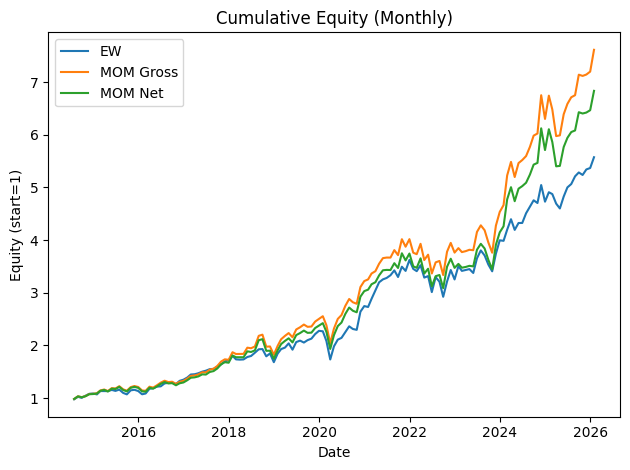

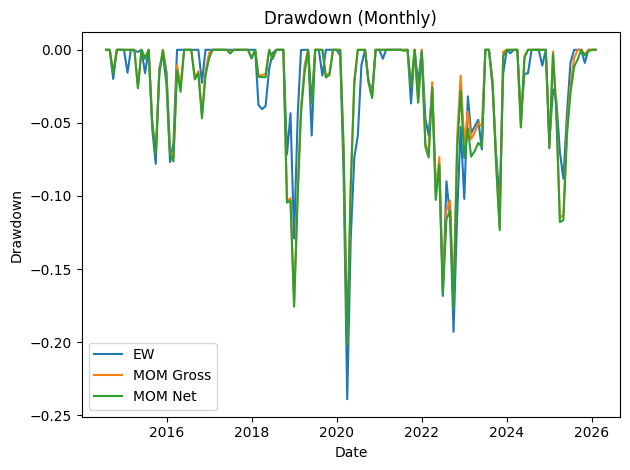

2026-01-26 17:35:30,909 | INFO | qp2 | [Cell12] Done. Equity final: EW=5.575, MOM_G=7.616, MOM_N=6.836


,EW,MOM_GROSS,MOM_NET
date,,,
2025-09-30,5.285496,7.142764,6.429940
2025-10-31,5.238109,7.119707,6.405326
2025-11-30,5.342784,7.145546,6.423576
2025-12-31,5.370121,7.201006,6.468037
2026-01-31,5.575028,7.615537,6.835717


,EW,MOM_GROSS,MOM_NET
date,,,
2025-09-30,0.000000,0.000000,0.000000
2025-10-31,-0.008966,-0.003228,-0.003828
2025-11-30,0.000000,0.000000,-0.000990
2025-12-31,0.000000,0.000000,0.000000
2026-01-31,0.000000,0.000000,0.000000


In [27]:
# =========================================
# 12) 시각화: 누적수익률 + 드로우다운
#
# 목적:
# - EW(기준선), MOM12-1(gross), MOM12-1(net: 비용반영) 비교
# - 누적곡선 / 드로우다운 곡선 시각화
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

EW_PATH   = INTERIM_DIR / "portfolio_ew_monthly_20130619.parquet"
MOM_PATH  = INTERIM_DIR / "portfolio_mom12_1_monthly_20130619.parquet"
NET_PATH  = INTERIM_DIR / "portfolio_mom12_1_net_20130619.parquet"

ew = pd.read_parquet(EW_PATH)
ew["date"] = pd.to_datetime(ew["date"])
ew = ew.sort_values("date").set_index("date")

mom = pd.read_parquet(MOM_PATH)
mom["date"] = pd.to_datetime(mom["date"])
mom = mom.sort_values("date").set_index("date")

net = pd.read_parquet(NET_PATH)
net["date"] = pd.to_datetime(net["date"])
net = net.sort_values("date").set_index("date")

df = pd.DataFrame({
    "ret_ew": ew["ret_ew"],
    "ret_mom_gross": mom["ret_mom12_1"],
    "ret_mom_net": net["ret_net"],
}).dropna()

# 누적자산가치(1부터 시작)
equity = (1 + df).cumprod()
equity.columns = ["EW", "MOM_GROSS", "MOM_NET"]

# 드로우다운
dd = equity / equity.cummax() - 1
dd.columns = ["EW", "MOM_GROSS", "MOM_NET"]

# -----------------------------
# Plot 1) Equity curve
# -----------------------------
plt.figure()
plt.plot(equity.index, equity["EW"], label="EW")
plt.plot(equity.index, equity["MOM_GROSS"], label="MOM Gross")
plt.plot(equity.index, equity["MOM_NET"], label="MOM Net")
plt.title("Cumulative Equity (Monthly)")
plt.xlabel("Date")
plt.ylabel("Equity (start=1)")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# Plot 2) Drawdown
# -----------------------------
plt.figure()
plt.plot(dd.index, dd["EW"], label="EW")
plt.plot(dd.index, dd["MOM_GROSS"], label="MOM Gross")
plt.plot(dd.index, dd["MOM_NET"], label="MOM Net")
plt.title("Drawdown (Monthly)")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# Quick peek
# -----------------------------
logger.info("[Cell12] Done. Equity final: EW=%.3f, MOM_G=%.3f, MOM_N=%.3f",
            equity["EW"].iloc[-1], equity["MOM_GROSS"].iloc[-1], equity["MOM_NET"].iloc[-1])

display(equity.tail())
display(dd.tail())


In [28]:
# =========================================
# 13A) 성과 요약 테이블
#
# 목적:
# - CAGR / Vol / Sharpe / Max Drawdown 계산
# - EW vs MOM Gross vs MOM Net 정량 비교
# =========================================

import numpy as np
import pandas as pd

# 월간 수익률 시리즈 준비
ret = df.copy()  # df = Cell12에서 만든 월간 수익률 DataFrame
ret.columns = ["EW", "MOM_GROSS", "MOM_NET"]

# -----------------------------
# 보조 함수들
# -----------------------------
def cagr(r: pd.Series) -> float:
    n_months = r.notna().sum()
    return (1 + r).prod() ** (12 / n_months) - 1

def ann_vol(r: pd.Series) -> float:
    return r.std() * np.sqrt(12)

def sharpe(r: pd.Series) -> float:
    vol = ann_vol(r)
    return np.nan if vol == 0 else cagr(r) / vol

def max_drawdown(r: pd.Series) -> float:
    equity = (1 + r).cumprod()
    dd = equity / equity.cummax() - 1
    return dd.min()

# -----------------------------
# 성과 테이블
# -----------------------------
summary = pd.DataFrame(
    {
        "CAGR": ret.apply(cagr),
        "Ann.Vol": ret.apply(ann_vol),
        "Sharpe": ret.apply(sharpe),
        "MaxDD": ret.apply(max_drawdown),
    }
)

# 보기 좋게 %
summary["CAGR"] = summary["CAGR"] * 100
summary["Ann.Vol"] = summary["Ann.Vol"] * 100
summary["MaxDD"] = summary["MaxDD"] * 100

summary = summary.round(2)

display(summary)

logger.info("[Cell13A] Performance summary done.")


,CAGR,Ann.Vol,Sharpe,MaxDD
EW,15.99,15.89,1.01,-23.90
MOM_GROSS,19.16,16.72,1.15,-20.10
MOM_NET,18.05,16.71,1.08,-20.23


2026-01-26 17:39:13,668 | INFO | qp2 | [Cell13A] Performance summary done.


In [29]:
# =========================================
# 13B) 통계적 유의성: Alpha / t-stat / IR
#
# 기준:
# - EW를 benchmark로 한 초과수익
# =========================================

import numpy as np
import pandas as pd

# 월간 초과수익 (Net - EW)
excess = ret["MOM_NET"] - ret["EW"]

# 표본 수
T = excess.notna().sum()

# 월간 평균 초과수익
mean_excess = excess.mean()

# 월간 표준편차
std_excess = excess.std()

# t-stat (H0: mean_excess = 0)
t_stat = mean_excess / (std_excess / np.sqrt(T))

# 연환산 정보비율(IR)
ir = (mean_excess * 12) / (std_excess * np.sqrt(12))

out = pd.DataFrame(
    {
        "Monthly Alpha (%)": [mean_excess * 100],
        "t-stat": [t_stat],
        "Information Ratio": [ir],
        "N (months)": [T],
    },
    index=["MOM_NET - EW"],
).round(3)

display(out)

logger.info("[Cell13B] Alpha test done.")


,Monthly Alpha (%),t-stat,Information Ratio,N (months)
MOM_NET - EW,0.159,0.901,0.265,139


2026-01-26 17:40:10,572 | INFO | qp2 | [Cell13B] Alpha test done.
